# Kaprekar's Constant
## Beautiful Dead Ends

---

### A different kind of dead end

The Collatz Conjecture and Hadwiger's Conjecture are dead ends in the sense that everyone who approaches them runs into a wall. The mystery deepens the more you look.

Kaprekar's constant is a dead end of a completely different kind. The mystery is real — the first time you see it, it's genuinely surprising. But the mystery dissolves completely once you understand what's happening. There's no wall. The explanation is elegant, complete, and short.

That makes it worth including in this series for the contrast. Not all beautiful dead ends are hard. Some are beautiful precisely because the path through them is so clean.

---

### The phenomenon

Take any four-digit number where not all digits are the same. Arrange its digits in descending order to make the largest possible number, and in ascending order to make the smallest. Subtract the smaller from the larger. Repeat with the result.

You will always reach **6174**.

Always. In at most 7 steps.

6174 is Kaprekar's constant.

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, Counter

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
NEUTRAL = '#888888'
WHITE   = '#dddddd'
BLUE    = '#5c9ee0'
GREEN   = '#5ce08a'

def kaprekar_step(n):
    """One Kaprekar operation: sort digits descending - ascending."""
    digits     = sorted(f'{n:04d}')
    ascending  = int(''.join(digits))
    descending = int(''.join(reversed(digits)))
    return descending - ascending

def kaprekar_sequence(n, max_steps=20):
    """Full sequence from n until 6174 is reached."""
    seq = [n]
    while seq[-1] != 6174 and len(seq) <= max_steps:
        seq.append(kaprekar_step(seq[-1]))
    return seq

def is_valid(n):
    """Valid starting numbers: 4-digit, not all same digit."""
    return 1000 <= n <= 9999 and len(set(f'{n:04d}')) > 1

print('Setup complete.')
print()
print('Demonstration:')
for start in [1234, 9876, 3087, 7652, 1000]:
    if not is_valid(start): continue
    seq = kaprekar_sequence(start)
    print(f'  {start:4d}: {" → ".join(str(x) for x in seq)}')

Setup complete.

Demonstration:
  1234: 1234 → 3087 → 8352 → 6174
  9876: 9876 → 3087 → 8352 → 6174
  3087: 3087 → 8352 → 6174
  7652: 7652 → 5085 → 7992 → 7173 → 6354 → 3087 → 8352 → 6174
  1000: 1000 → 999 → 8991 → 8082 → 8532 → 6174


## Part 1: Verify it universally

Before asking why, establish that it actually holds for every valid 4-digit number.

In [3]:
step_counts = Counter()
exceptions  = []

for n in range(1000, 10000):
    if not is_valid(n):
        continue
    seq = kaprekar_sequence(n)
    if seq[-1] != 6174:
        exceptions.append(n)
    else:
        step_counts[len(seq) - 1] += 1

print(f'Valid 4-digit numbers tested: {sum(step_counts.values())}')
print(f'Exceptions (did not reach 6174): {len(exceptions)}')
print()
print('Steps to reach 6174:')
for steps in sorted(step_counts):
    bar = '█' * (step_counts[steps] // 50)
    print(f'  {steps} step{"s" if steps!=1 else " "}: {step_counts[steps]:5d}  {bar}')
print(f'  Maximum steps needed: {max(step_counts)}')

Valid 4-digit numbers tested: 8991
Exceptions (did not reach 6174): 0

Steps to reach 6174:
  0 steps:     1  
  1 step :   356  ███████
  2 steps:   519  ██████████
  3 steps:  2124  ██████████████████████████████████████████
  4 steps:  1124  ██████████████████████
  5 steps:  1379  ███████████████████████████
  6 steps:  1508  ██████████████████████████████
  7 steps:  1980  ███████████████████████████████████████
  Maximum steps needed: 7


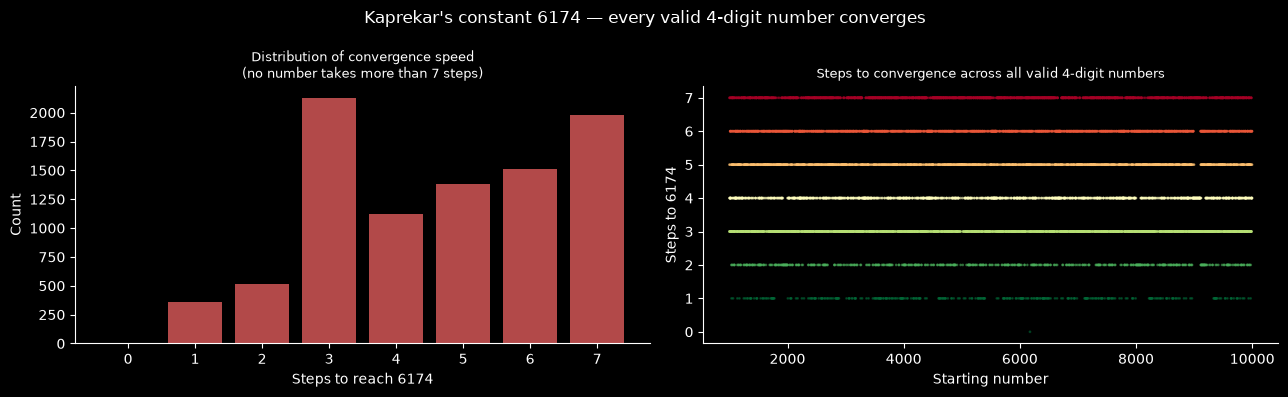

In [4]:
# Visualise: steps to convergence across all valid 4-digit numbers
step_data = {}
for n in range(1000, 10000):
    if is_valid(n):
        step_data[n] = len(kaprekar_sequence(n)) - 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Kaprekar's constant 6174 — every valid 4-digit number converges", fontsize=12)

# Left: step count distribution
ax = axes[0]
counts = Counter(step_data.values())
ax.bar(counts.keys(), counts.values(), color=ACCENT, alpha=0.8, edgecolor='none')
ax.set_xlabel('Steps to reach 6174', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('Distribution of convergence speed\n(no number takes more than 7 steps)', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: step count visualised across number line
ax = axes[1]
ns = list(step_data.keys())
ss = [step_data[n] for n in ns]
colours = [plt.cm.RdYlGn_r(s/7) for s in ss]
ax.scatter(ns, ss, c=ss, cmap='RdYlGn_r', s=1, alpha=0.5, vmin=1, vmax=7)
ax.set_xlabel('Starting number', fontsize=10)
ax.set_ylabel('Steps to 6174', fontsize=10)
ax.set_title('Steps to convergence across all valid 4-digit numbers', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Part 2: Why step 1 always gives a multiple of 9

Any number whose digit sum is 9 is divisible by 9. 6+1+7+4 = 18 = 1+8 = 9. And 6174 ÷ 9 = 686. So 6174 is divisible by 9.

That's not a coincidence — it's a consequence of a simple fact about how 9 and powers of 10 interact.

**The key fact:** 10 ≡ 1 (mod 9). Therefore 10^k ≡ 1 (mod 9) for every k.

This means the value of a number mod 9 equals its **digit sum** mod 9. That's why "casting out nines" works in arithmetic.

Now: when you rearrange the digits of a number to form the largest and smallest possible arrangements, both have **the same digits** — just in different order. So both have the same digit sum, and therefore the same value mod 9.

Descending − Ascending ≡ 0 (mod 9).

After one Kaprekar step, we are always in the multiples of 9. And we stay there — the operation preserves this, because we're always subtracting a multiple of 9 from a multiple of 9.

In [5]:
# Prove it: the first step always lands on a multiple of 9
print('Verifying: first Kaprekar step is always divisible by 9')
print()
non_multiples = []
for n in range(1000, 10000):
    if not is_valid(n): continue
    result = kaprekar_step(n)
    if result % 9 != 0:
        non_multiples.append(n)

print(f'Non-multiples of 9 after step 1: {len(non_multiples)}')
print(f'All results are multiples of 9: {len(non_multiples) == 0}')
print()

# Show the mod 9 arithmetic
print('The arithmetic:')
print('10^k mod 9 for k = 0, 1, 2, 3:')
for k in range(4):
    print(f'  10^{k} = {10**k:5d}, mod 9 = {10**k % 9}')
print()
print('Every power of 10 is ≡ 1 (mod 9).')
print('So every rearrangement of the same digits has the same value mod 9.')
print('Descending − Ascending ≡ 0 (mod 9). Always.')
print()

# Demonstrate with examples
print('Examples:')
for n in [2736, 5183, 8001, 1470]:
    if not is_valid(n): continue
    digits = sorted(f'{n:04d}')
    asc  = int(''.join(digits))
    desc = int(''.join(reversed(digits)))
    diff = desc - asc
    dsum = sum(int(d) for d in f'{diff:04d}')
    print(f'  {n}: {desc} − {asc:04d} = {diff:4d}, digit sum = {dsum}, div by 9: {diff % 9 == 0}')

Verifying: first Kaprekar step is always divisible by 9

Non-multiples of 9 after step 1: 0
All results are multiples of 9: True

The arithmetic:
10^k mod 9 for k = 0, 1, 2, 3:
  10^0 =     1, mod 9 = 1
  10^1 =    10, mod 9 = 1
  10^2 =   100, mod 9 = 1
  10^3 =  1000, mod 9 = 1

Every power of 10 is ≡ 1 (mod 9).
So every rearrangement of the same digits has the same value mod 9.
Descending − Ascending ≡ 0 (mod 9). Always.

Examples:
  2736: 7632 − 2367 = 5265, digit sum = 18, div by 9: True
  5183: 8531 − 1358 = 7173, digit sum = 18, div by 9: True
  8001: 8100 − 0018 = 8082, digit sum = 18, div by 9: True
  1470: 7410 − 0147 = 7263, digit sum = 18, div by 9: True


## Part 3: Why 6174 specifically?

The mod 9 argument explains why we always land in multiples of 9. But there are many 4-digit multiples of 9 — 1000 of them. Why does the iteration always converge to 6174 specifically and not some other multiple of 9?

The answer: **6174 is the unique fixed point** of the Kaprekar operation among 4-digit numbers. Apply the operation to 6174 and you get 6174 back. Apply it to any other 4-digit multiple of 9, and you don't.

And the whole functional graph of 4-digit numbers under Kaprekar is a tree rooted at 6174 — every node has a path to the root.

In [6]:
# Find all fixed points of the Kaprekar operation
print('Fixed points of the Kaprekar operation (4-digit numbers):')
fixed_points = []
for n in range(1000, 10000):
    if not is_valid(n): continue
    if kaprekar_step(n) == n:
        fixed_points.append(n)
        print(f'  {n}: {sorted(f"{n:04d}")} → {int("".join(reversed(sorted(f"{n:04d}"))))} − {int("".join(sorted(f"{n:04d}")))} = {kaprekar_step(n)}')

print(f'\nTotal fixed points: {len(fixed_points)}')
print(f'6174 is the unique fixed point.')
print()
print('Verify: 6174 → 7641 − 1467 =', 7641 - 1467)
print('Digit check: 7,6,4,1 arranged descending = 7641, ascending = 1467')

Fixed points of the Kaprekar operation (4-digit numbers):
  6174: ['1', '4', '6', '7'] → 7641 − 1467 = 6174

Total fixed points: 1
6174 is the unique fixed point.

Verify: 6174 → 7641 − 1467 = 6174
Digit check: 7,6,4,1 arranged descending = 7641, ascending = 1467


In [7]:
# What values actually appear in Kaprekar sequences?
# There should be very few — the map collapses most of the space

all_values = set()
predecessors = defaultdict(set)

for n in range(1000, 10000):
    if not is_valid(n): continue
    result = kaprekar_step(n)
    all_values.add(n)
    all_values.add(result)
    predecessors[result].add(n)

# The image of the map — values that actually appear as outputs
image = set(kaprekar_step(n) for n in range(1000, 10000) if is_valid(n))

print(f'Unique values in the image of the Kaprekar map: {len(image)}')
print(f'(Out of 8,991 valid inputs)')
print()
print('These are the only values a Kaprekar sequence can pass through:')
print(sorted(image))
print()
print(f'Numbers mapping directly to 6174 (one step): {len(predecessors[6174])}')
print(f'First 10: {sorted(predecessors[6174])[:10]}')

Unique values in the image of the Kaprekar map: 54
(Out of 8,991 valid inputs)

These are the only values a Kaprekar sequence can pass through:
[999, 1089, 1998, 2088, 2178, 2997, 3087, 3177, 3267, 3996, 4086, 4176, 4266, 4356, 4995, 5085, 5175, 5265, 5355, 5445, 5994, 6084, 6174, 6264, 6354, 6444, 6534, 6993, 7083, 7173, 7263, 7353, 7443, 7533, 7623, 7992, 8082, 8172, 8262, 8352, 8442, 8532, 8622, 8712, 8991, 9081, 9171, 9261, 9351, 9441, 9531, 9621, 9711, 9801]

Numbers mapping directly to 6174 (one step): 357
First 10: [1036, 1063, 1137, 1173, 1247, 1274, 1306, 1317, 1357, 1360]


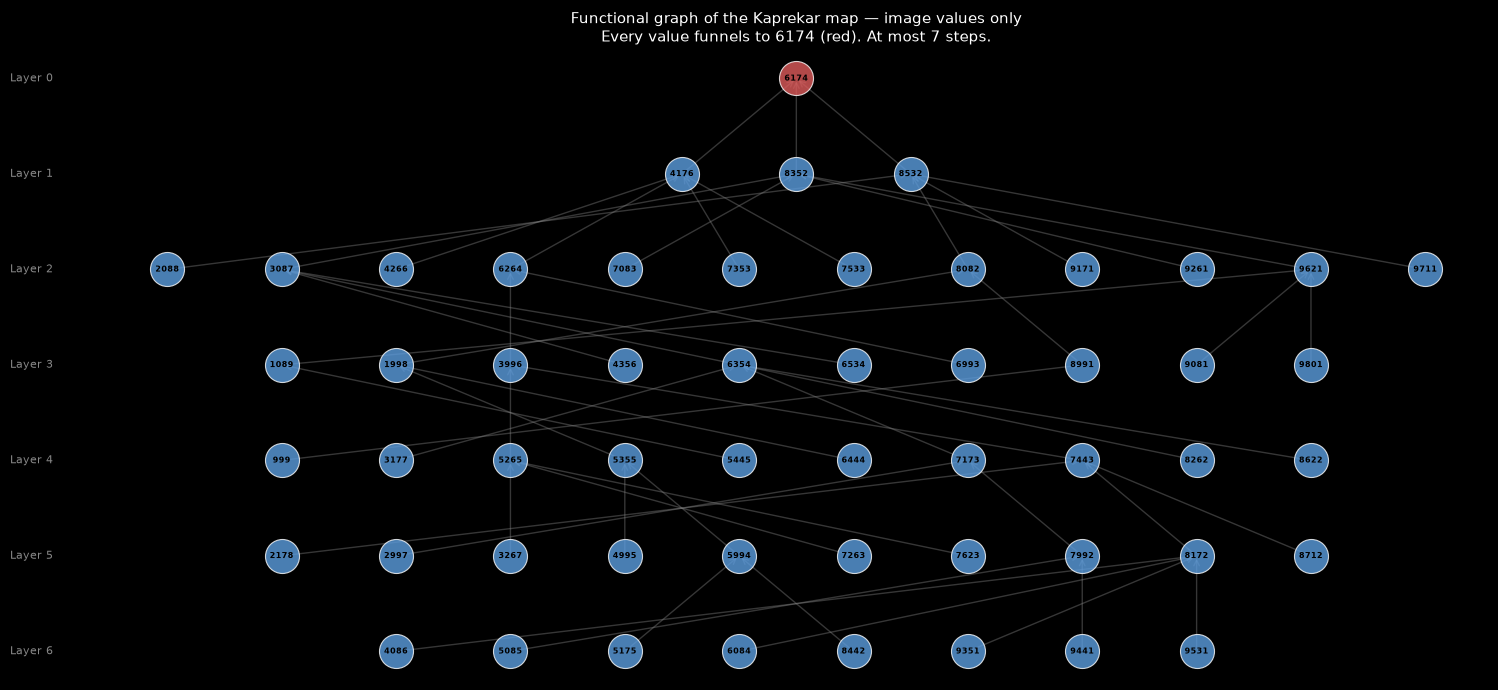

Layers in the image graph: 6
Nodes per layer: {0: 1, 1: 3, 2: 12, 3: 10, 4: 10, 5: 10, 6: 8}


In [8]:
# Draw the functional graph — the tree structure converging to 6174
# Show only the image values (the ~55 nodes that matter)
# and how they connect to each other

img_list = sorted(image)
img_set  = set(img_list)

# Build edges among image values
img_edges = {}
for v in img_list:
    if v == 6174: continue
    nxt = kaprekar_step(v)
    img_edges[v] = nxt

# Assign layers by distance to 6174
layers = {6174: 0}
changed = True
while changed:
    changed = False
    for v, nxt in img_edges.items():
        if v not in layers and nxt in layers:
            layers[v] = layers[nxt] + 1
            changed = True

max_layer = max(layers.values())
from collections import defaultdict
by_layer = defaultdict(list)
for v, l in layers.items():
    by_layer[l].append(v)

# Position nodes
pos = {}
for layer, nodes in by_layer.items():
    for i, v in enumerate(sorted(nodes)):
        pos[v] = (i - len(nodes)/2, -layer)

fig, ax = plt.subplots(figsize=(15, 7))

# Draw edges
for v, nxt in img_edges.items():
    if v in pos and nxt in pos:
        ax.annotate('', xy=pos[nxt], xytext=pos[v],
                    arrowprops=dict(arrowstyle='->', color=NEUTRAL, alpha=0.4, lw=1))

# Draw nodes
for v, (x, y) in pos.items():
    colour = ACCENT if v == 6174 else BLUE
    ax.scatter(x, y, s=600, color=colour, alpha=0.8, zorder=3,
               edgecolors='white', linewidth=0.8)
    ax.text(x, y, str(v), ha='center', va='center',
            fontsize=6, color='black', fontweight='bold', zorder=4)

# Layer labels
for layer in range(max_layer+1):
    y_pos = -layer
    ax.text(-max(len(by_layer[l]) for l in by_layer)/2 - 1, y_pos,
            f'Layer {layer}', ha='right', va='center', fontsize=8, color=NEUTRAL)

ax.set_title('Functional graph of the Kaprekar map — image values only\n'
             'Every value funnels to 6174 (red). At most 7 steps.',
             fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Layers in the image graph: {max_layer}')
print(f'Nodes per layer: {dict(sorted({l: len(v) for l, v in by_layer.items()}.items()))}')

## Part 4: The complete explanation

We can now say exactly why Kaprekar's constant works. There are three parts:

**Part 1 — The mod 9 constraint.** Since 10 ≡ 1 (mod 9), every power of 10 is congruent to 1 mod 9. This means the value of a number mod 9 equals its digit sum mod 9. When you rearrange digits, the digit sum doesn't change, so the value mod 9 doesn't change. Descending − Ascending has two numbers with the same digit sum, so their difference is 0 mod 9. After one step, we're in the multiples of 9 — and we stay there.

**Part 2 — The image is small.** The Kaprekar map from 8,991 valid inputs produces only ~55 distinct outputs. Most of the 4-digit space collapses immediately to a small set of values.

**Part 3 — The unique fixed point.** Among all values in this small image, 6174 is the only fixed point. Everything else maps to something else. Since the image is finite and the map is deterministic, every chain must eventually cycle — and the only cycle is the fixed point 6174.

That's it. The "mystery" of Kaprekar's constant is entirely explained by:
- Elementary modular arithmetic (the mod 9 argument)
- The small size of the image
- The uniqueness of the fixed point

No number theory beyond secondary school. No open problems. The mystery dissolves completely.

In [9]:
# Final summary: the complete proof in code
print('=== The complete explanation, step by step ===')
print()
print('Step 1: After one Kaprekar operation, result is always divisible by 9.')
non_div9 = sum(1 for n in range(1000,10000) if is_valid(n) and kaprekar_step(n) % 9 != 0)
print(f'  Violations: {non_div9} (should be 0)')
print()

print('Step 2: The image of the Kaprekar map is tiny.')
print(f'  Input space: 8,991 valid 4-digit numbers')
print(f'  Image size:  {len(image)} distinct output values')
print(f'  Compression: {len(image)/8991*100:.1f}% of inputs survive as distinct outputs')
print()

print('Step 3: 6174 is the unique fixed point.')
print(f'  Fixed points found: {len(fixed_points)}')
print(f'  The fixed point is: {fixed_points}')
print()

print('Conclusion: Since the image is finite, every chain must eventually cycle.')
print('Since 6174 is the only fixed point and there are no other cycles,')
print('every chain reaches 6174. In at most 7 steps.')
print()
print('The mystery dissolves. It is elementary arithmetic.')

=== The complete explanation, step by step ===

Step 1: After one Kaprekar operation, result is always divisible by 9.
  Violations: 0 (should be 0)

Step 2: The image of the Kaprekar map is tiny.
  Input space: 8,991 valid 4-digit numbers
  Image size:  54 distinct output values
  Compression: 0.6% of inputs survive as distinct outputs

Step 3: 6174 is the unique fixed point.
  Fixed points found: 1
  The fixed point is: [6174]

Conclusion: Since the image is finite, every chain must eventually cycle.
Since 6174 is the only fixed point and there are no other cycles,
every chain reaches 6174. In at most 7 steps.

The mystery dissolves. It is elementary arithmetic.


## A note on other digit lengths

Kaprekar's constant is specific to 4-digit numbers. Other digit lengths behave differently:

- **3-digit numbers** converge to **495** (also unique fixed point)
- **5-digit numbers** have no single fixed point — they enter cycles between multiple values
- **6-digit numbers** converge to either 549945 or 631764 depending on starting value
- **2-digit numbers** don't converge at all

The same mod 9 argument applies to all lengths — the operation always produces a multiple of 9. But the uniqueness of the fixed point is specific to 3 and 4 digits. For 5+ digits, the image graph has multiple attractors or cycles, and the neat single-constant behaviour breaks down.

That's also not a mystery — it's a consequence of how many distinct digit multisets of a given length produce multiples of 9, and how the Kaprekar map acts on those. The 4-digit case happens to have exactly one fixed point. Other lengths don't.

In [10]:
# Verify 3-digit Kaprekar constant = 495
def kaprekar_step_n(n, digits=3):
    fmt = f'{{:0{digits}d}}'
    d = sorted(fmt.format(n))
    return int(''.join(reversed(d))) - int(''.join(d))

print('3-digit Kaprekar behaviour:')
fixed_3 = [n for n in range(100, 1000)
           if len(set(f'{n:03d}')) > 1 and kaprekar_step_n(n, 3) == n]
print(f'Fixed points: {fixed_3}')

print('\nExample sequences (3-digit):')
for start in [753, 123, 999-1, 100]:
    if len(set(f'{start:03d}')) <= 1: continue
    seq = [start]
    while seq[-1] != 495 and len(seq) < 10:
        seq.append(kaprekar_step_n(seq[-1], 3))
    print(f'  {start}: {" → ".join(str(x) for x in seq)}')

print()
print('5-digit Kaprekar behaviour — does it have a single fixed point?')
fixed_5 = [n for n in range(10000, 100000)
           if len(set(f'{n:05d}')) > 1 and kaprekar_step_n(n, 5) == n]
print(f'Fixed points (5-digit): {fixed_5}')
print('No single constant — 5-digit numbers enter cycles instead.')

3-digit Kaprekar behaviour:
Fixed points: [495]

Example sequences (3-digit):
  753: 753 → 396 → 594 → 495
  123: 123 → 198 → 792 → 693 → 594 → 495
  998: 998 → 99 → 891 → 792 → 693 → 594 → 495
  100: 100 → 99 → 891 → 792 → 693 → 594 → 495

5-digit Kaprekar behaviour — does it have a single fixed point?
Fixed points (5-digit): []
No single constant — 5-digit numbers enter cycles instead.


## What makes this a beautiful dead end

Kaprekar's constant is a beautiful dead end for the opposite reason from Collatz and Hadwiger. Those problems are dead ends because you keep going and can never get through. This one is a dead end because you get through immediately — and then there's nothing left to wonder about.

The explanation is complete. The proof requires no advanced mathematics. The mystery dissolves entirely once you see the three components: mod 9 forces the image into multiples of 9, the image collapses to a small finite set, and 6174 is the unique fixed point of the map on that set.

What makes it beautiful is that none of that is obvious until you look. The phenomenon looks surprising. The explanation, when it arrives, feels like the right explanation — not a brute-force exhaustion of cases but a genuinely illuminating account of why something has to be true.

That's the contrast with the other problems in this series. Collatz: the mystery deepens every time you look. Hadwiger: the proof tools ran out and nobody knows what to do next. Kaprekar: look once, understand completely, move on.

All three are beautiful. The beauty is just a different shape each time.

---

*Next in the series: untouchable numbers — a problem that sits between "obviously true for structural reasons" and "nobody can prove it", in a way that bears some similarity to Goldbach's Conjecture.*